In [63]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
#import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

def custom_grouping(index):
    return index // 1000

names_bw=['time', 'bw', 'op1', 'size', 'op2' ]
names_latency=['time', 'latency', 'op2', 'write_size', 'op3']

In [64]:
# This is the 90/10 zipf random writes  pattern for DMHybrid (aka STL in the notebooks)
# The path should be /p5/worst_case/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log

In [65]:
# Define a custom grouping function
  
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
#df = pd.read_csv(f'/home/surbhi/measurements/worst_case/STL/1M/90-10-LBA/90Util/run1/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df = pd.read_csv(f'/home/surbhi/measurements/CMR/90-10-LBA/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 1048576
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)
last_non_zero_index = data_written_ms[data_written_ms.ne(0).any(axis=1)].index[-1]
data_written_ms = data_written_ms.loc[:last_non_zero_index]

/tmp/ipykernel_10301/4056193804.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.61156302
 2428.61156302 2428.61156302 2428.61156302 2428.61156302 2428.

35839


In [66]:
#assert math.ceil(data_written_ms.data_written_bytes.sum()) == len(df)*4096
print(math.ceil(data_written_ms.data_written_bytes.sum()))
print(len(df) * 1048576)

37580963840
37580963840


In [67]:
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
df_grouped.reset_index(drop=True, inplace=True)
last_non_zero_index = df_grouped[df_grouped.ne(0).any(axis=1)].index[-1]
df_grouped = df_grouped.loc[:last_non_zero_index]
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_grouped.describe())
print(df_grouped.info())


data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'

            index  data_written_bytes  cumulative_gb
count  358.000000          358.000000     358.000000
mean   178.500000          100.111732      17.803520
std    103.489935           20.531188      10.097888
min      0.000000            5.437957       0.136762
25%     89.250000           86.988495       9.176952
50%    178.500000          101.193340      17.758117
75%    267.750000          114.496610      26.629056
max    357.000000          152.013027      35.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               358 non-null    int64  
 1   data_written_bytes  358 non-null    float64
 2   cumulative_gb       358 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 8.5 KB
None
Average1: 82
Average2: 115


The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 5.437956552664142
The highest duration: 1750.571114


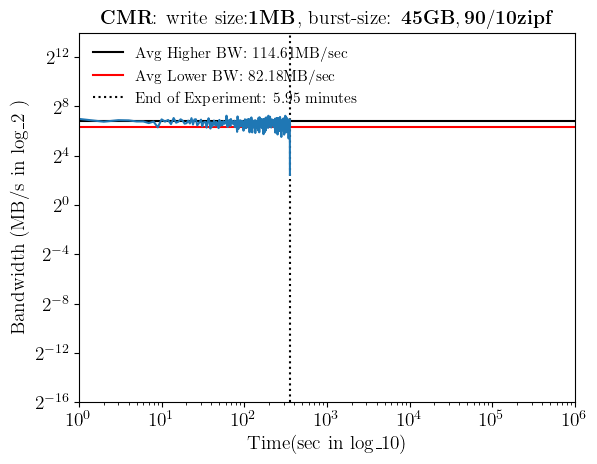

357


In [68]:
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
max_duration = max(df['duration'])
print(f"The highest duration: {max_duration}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)
#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines
xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper left', fontsize=11, frameon=False)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\bf{CMR}$: write size:$\bf{1MB}$, burst-size: $\bf{45GB}, 90/10 zipf$", fontsize=14)    
plt.savefig('/home/surbhi/Downloads/1M_9010_CMR_BW.png', bbox_inches='tight', dpi=300)
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/3006084451.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.96632123
 1484.96632123 1484.96632123 1484.96632123 1484.96632123 1484.

46079
Min Idx: 
553
Average1: 71
Average2: 93


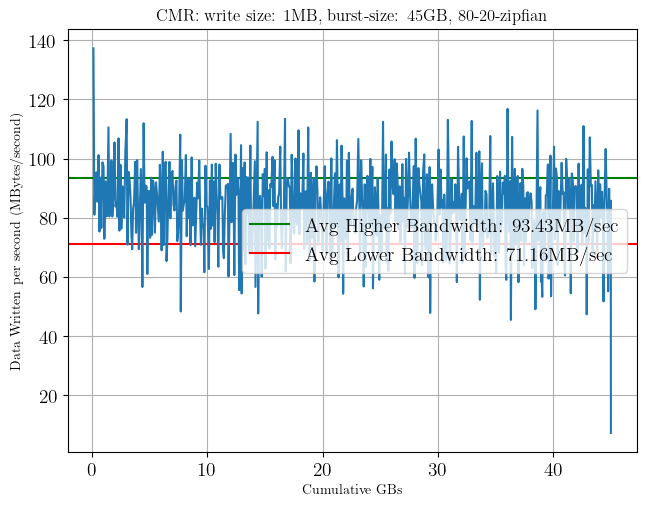

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 7.292640464361899


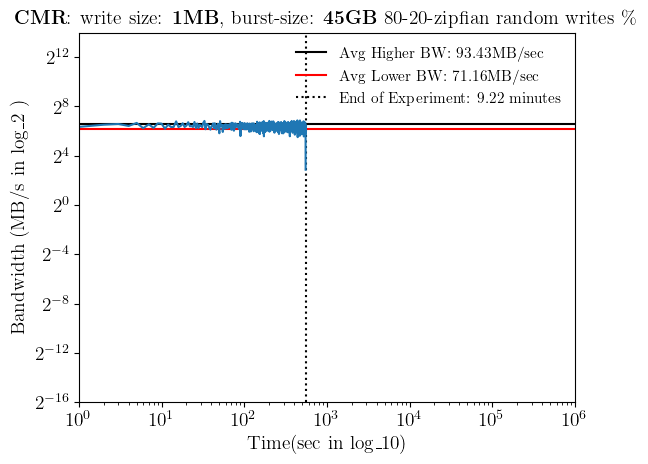

553


In [69]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/80-20-LBA/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/1M_80_20_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{1MB}$, burst-size: $\textbf{45GB}$ 80-20-zipfian random writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/2002373438.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.52236774
 2051.52236774 2051.52236774 2051.52236774 2051.52236774 2051.

35839
Min Idx: 
447
Average1: 73
Average2: 87


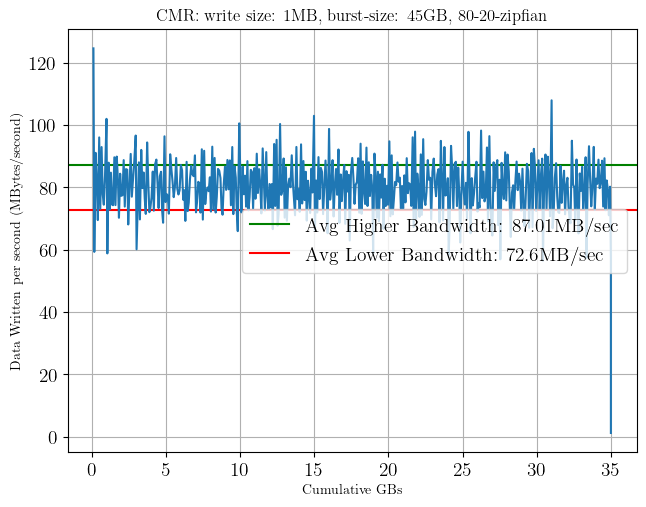

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 1.2178116248650523


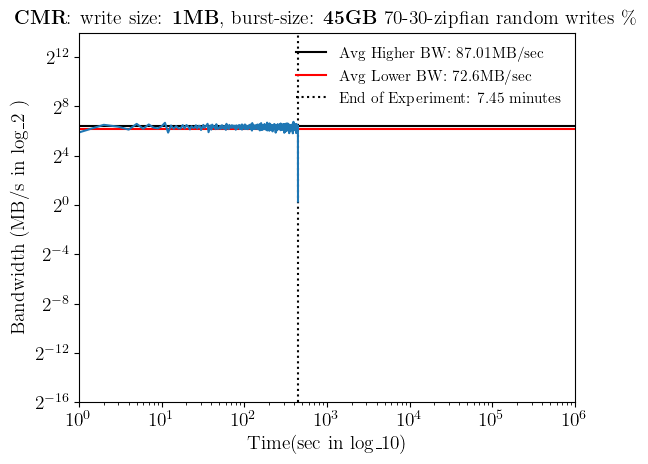

447


In [70]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/70-30-LBA/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/1M_70_30_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{1MB}$, burst-size: $\textbf{45GB}$ 70-30-zipfian random writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/983386400.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.56186762
 1542.56186762 1542.56186762 1542.56186762 1542.56186762 1542.5

46079
Min Idx: 
572
Average1: 74
Average2: 88


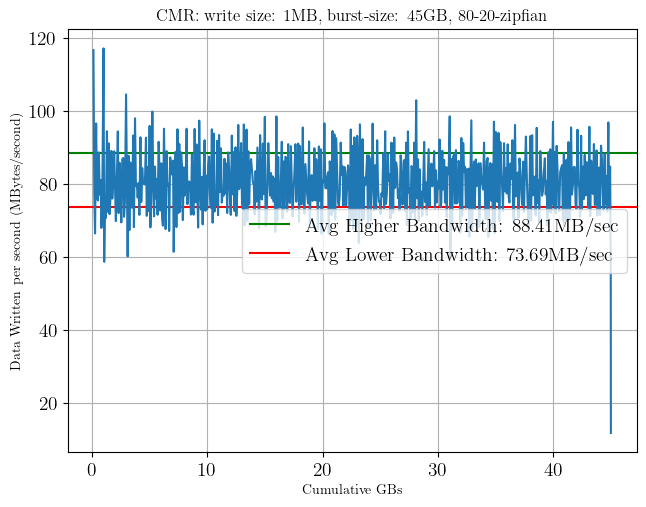

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 11.69351889840565


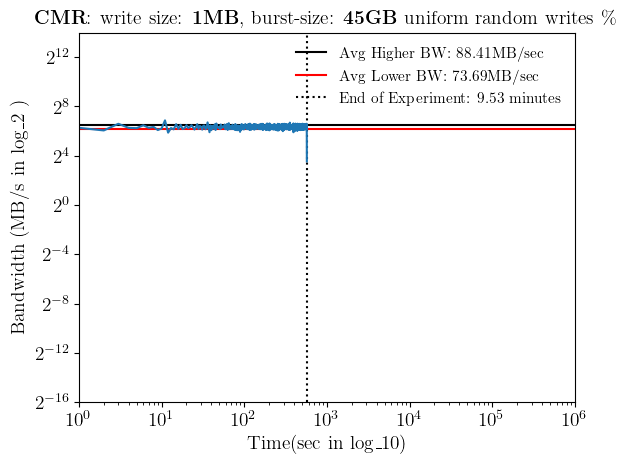

572


In [71]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/uniform-random/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/1M_uniform_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{1MB}$, burst-size: $\textbf{45GB}$ uniform random writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/1054983581.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.02984719
 5703.02984719 5703.02984719 5703.02984719 5703.02984719 5703.

33791
Min Idx: 
294
Average1: 111
Average2: 124


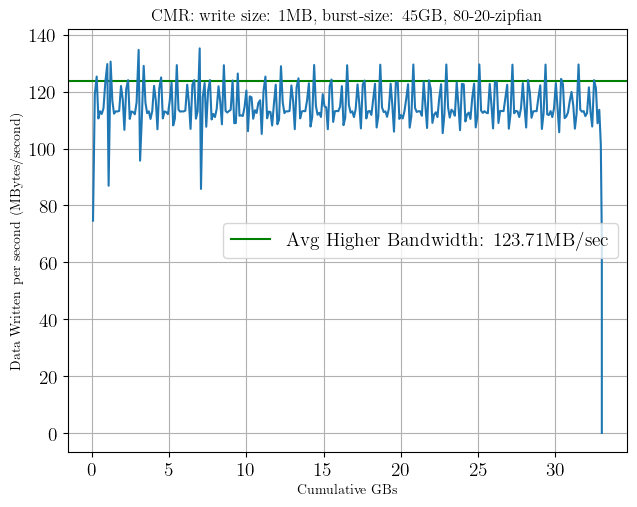

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.028967018758831495


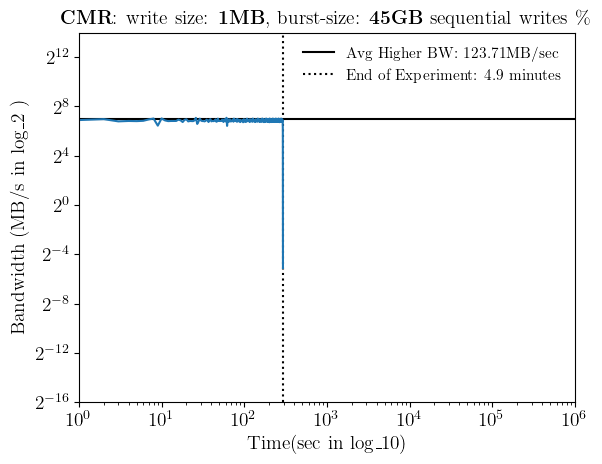

294


In [72]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/sequential/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/1M_sequential_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{1MB}$, burst-size: $\textbf{45GB}$ sequential writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

In [ ]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/uniform/1M/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = (1024 * 1024)
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 1MB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/1M_sequential_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{1MB}$, burst-size: $\textbf{45GB}$ sequential writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/3230469629.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218 5.85318218
 5.85318218 5.85318218 5.85318218 5.853

1310719
Min Idx: 
1324
Average1: 2
Average2: 2


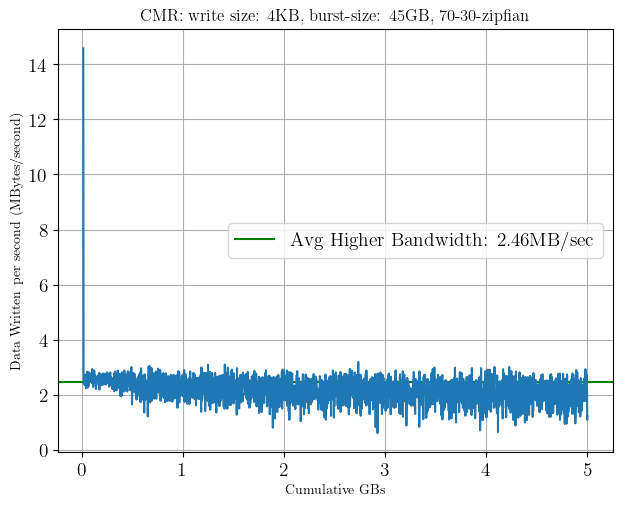

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.6153211493176483


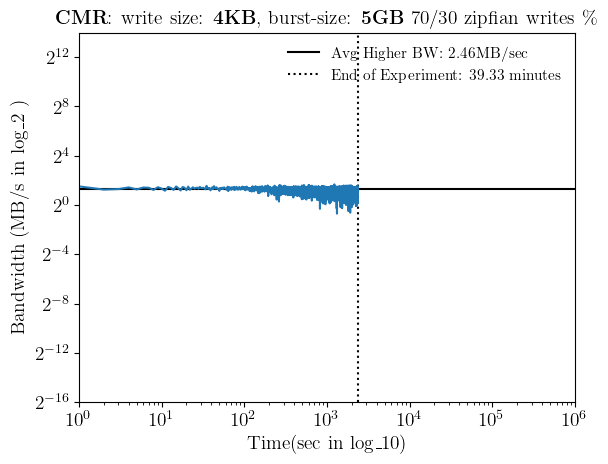

2360


In [ ]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/90-10-LBA/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 5GB, 90-10-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_90_10_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ 90/10 zipfian writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/1213580850.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617 5.84086617
 5.84086617 5.84086617 5.84086617 5.840

1310719
Min Idx: 
3040
Average1: 1
Average2: 2


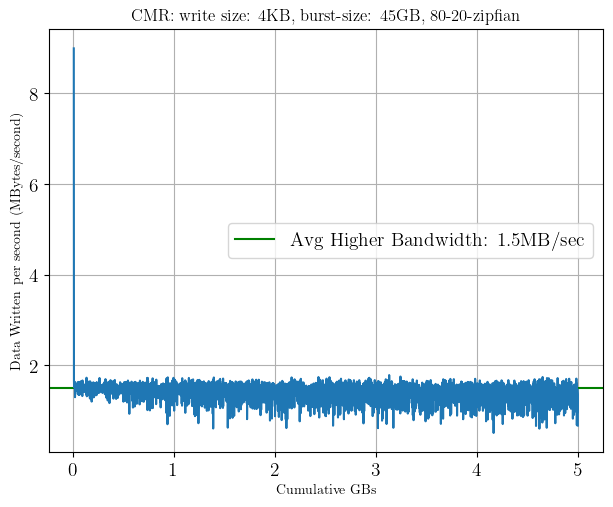

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.512054827871013


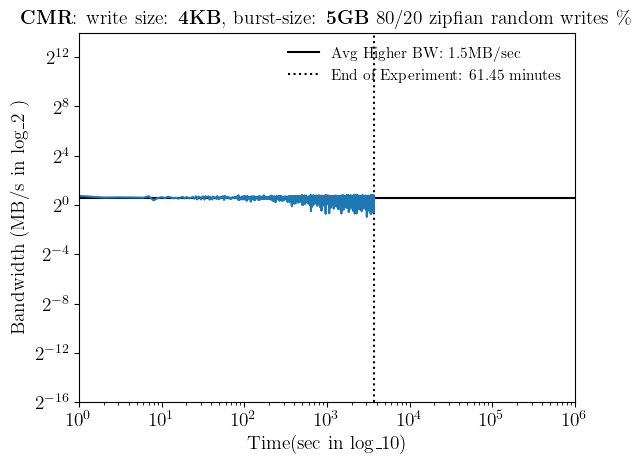

3687


In [74]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/80-20-LBA/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 45GB, 80-20-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_80_20_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ 80/20 zipfian random writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/1344695821.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722
 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6.1189722 6

1310719
Min Idx: 
4176
Average1: 1
Average2: 7


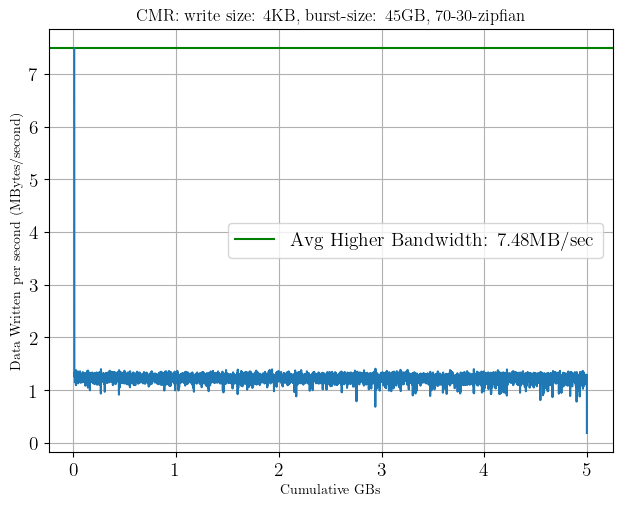

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.18712829488179272


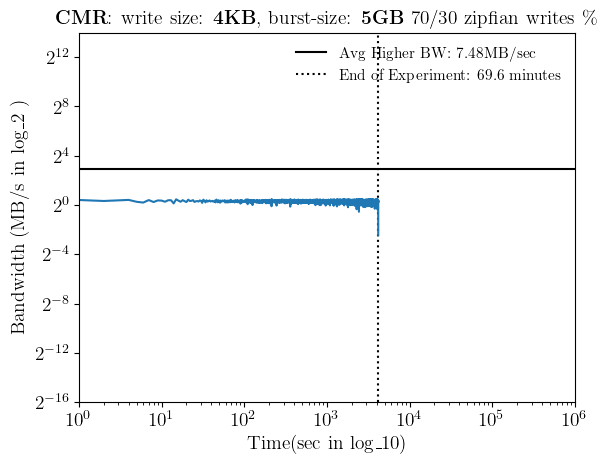

4176


In [75]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/70-30-LBA/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 45GB, 70-30-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_70_30_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ 70/30 zipfian writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/882740154.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1912.74233829 1912.74233829]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_written_ms.loc[start:end-1] += write_rate_per_ms


1310719
Min Idx: 
4163
Average1: 1
Average2: 1


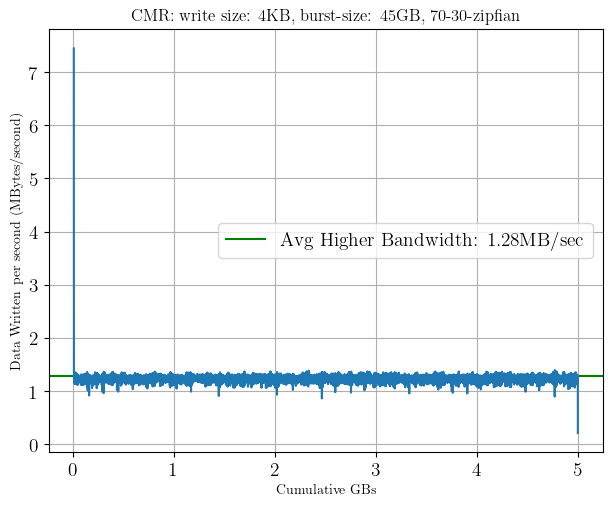

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.21197576910613047


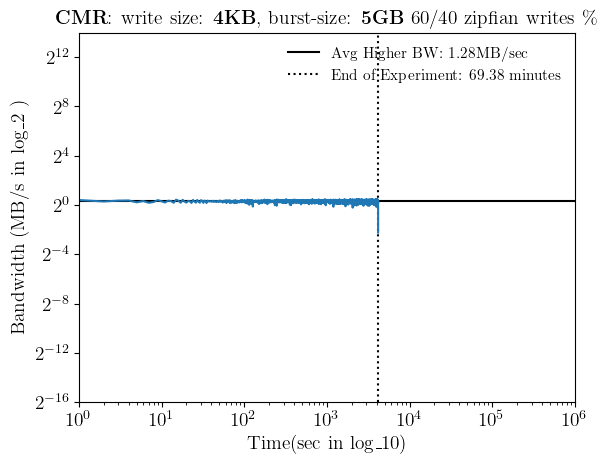

4163


In [76]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/60-40-LBA/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 45GB, 70-30-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_60_40_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ 60/40 zipfian writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/3981944319.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762 6.11318762
 6.11318762 6.11318762 6.11318762 6.113

1310719
Min Idx: 
4156
Average1: 1
Average2: 7


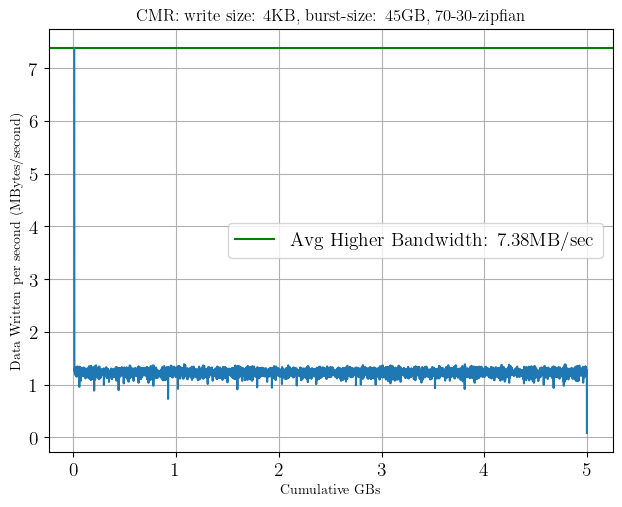

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 0.08387834636127468


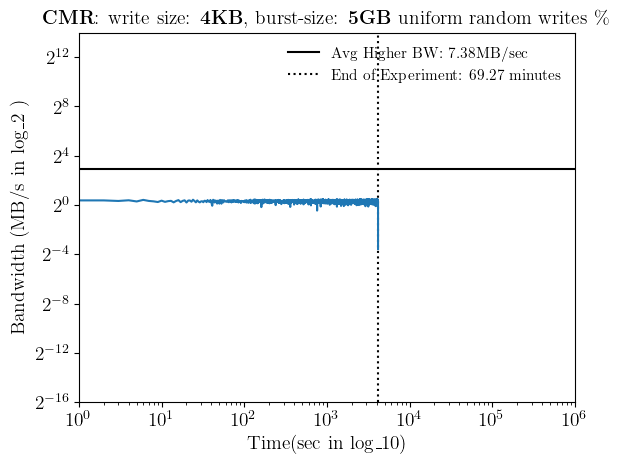

4156


In [77]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/uniform/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 45GB, 70-30-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_uniform_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ uniform random writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))

/tmp/ipykernel_10301/1975488272.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234 10.35877234
 10.35877234 10.35877234 10.35877234 10.

1310719
Min Idx: 
25
Average1: 12
Average2: 204


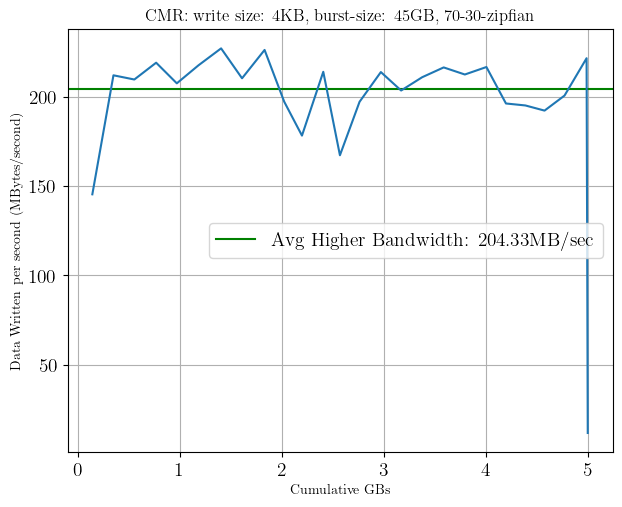

The lowest power of 2 beyond which the plot won't go: 1.52587890625e-05, 11.664963550159198


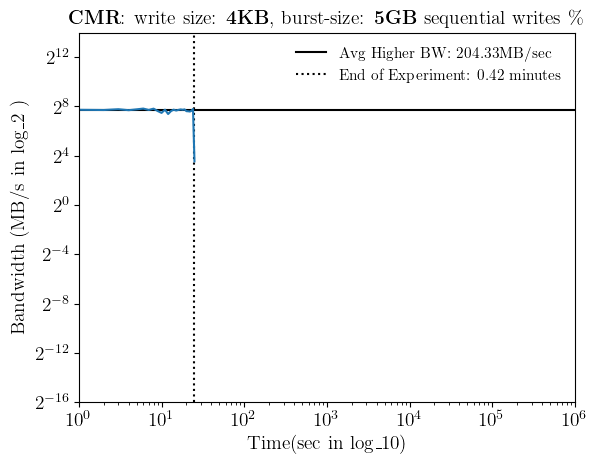

25


In [78]:
names_latency=['submission_time', 'duration', 'op2', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size']

# Step 1: Read the CSV file into a Pandas DataFrame
df = pd.read_csv(f'/home/surbhi/measurements/CMR/sequential/4K/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df['submission_time'] = np.floor(df['submission_time'] - df.iloc[0].submission_time)
df['duration'] = df['duration']/1e6 #convert ns to ms
df['completion_time'] = np.floor(df['submission_time'] + df['duration'])

# Step 3: Determine the start and end time of the entire test
start_time = int(df['submission_time'].min())
end_time = int(df['completion_time'].max())


# Step 4: Create new DataFrames to represent each  millisecond between the start and end time of the entire test
data_written_ms = pd.DataFrame(index=range(start_time, end_time + 1, 1), columns=['data_written_bytes'])
data_written_ms['data_written_bytes'] = 0

# Step 5: Iterate through each write request, calculate the data size for each time interval, and update the corresponding entries in the DataFrames
for index, row in df.iterrows():
    duration = row['duration']
    start = int(row['submission_time'])
    end = start+math.floor(duration)
    
    payload = 4096
    write_rate_per_ms = payload / max(duration, 1.)
    assert(write_rate_per_ms <= payload)
    residue = payload - write_rate_per_ms * math.floor(duration)
    assert (payload >= (write_rate_per_ms * math.floor(duration)))
    data_written_ms.loc[start:end-1] += write_rate_per_ms
    # residue could be zero when last == end
    data_written_ms.loc[end] += residue

print(index)
data_written_ms.reset_index(drop=True, inplace=True)

chunk_size = 10000
results = []
for i in range(0, len(data_written_ms), chunk_size):
    chunk = data_written_ms.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_grouped = pd.concat(results)

# Reset the index to make it a regular column
df_grouped.reset_index(inplace=True)
df_grouped['cumulative_gb'] = df_grouped['data_written_bytes'].cumsum() / (1024 ** 3)
df_grouped['data_written_bytes'] = df_grouped['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
#print(df_grouped.describe())
#print(df_grouped.info())
print("Min Idx: \n" + str(df_grouped['data_written_bytes'].idxmin()))

data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
kmeans = KMeans(n_clusters=2)
kmeans.fit(data_array)
# Get the cluster centers
cluster_centers = kmeans.cluster_centers_.flatten()
# Sort cluster centers to get the lowest and highest modes
cluster_centers.sort()
# Calculate the average of each mode
average_mode1 = cluster_centers[0]
average_mode2 = cluster_centers[1]
print("Average1: " + str(round(average_mode1, )))
print("Average2: " + str(round(average_mode2, )))
avg_bw_str1 = str(round(average_mode1, 2)) + 'MB/sec'
avg_bw_str2 = str(round(average_mode2, 2)) + 'MB/sec'
fig, ax = plt.subplots()
plt.axhline(y=average_mode2, color='g', linestyle='-', label='Avg Higher Bandwidth: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower Bandwidth: ' + avg_bw_str1)

# Plot vertical lines at x where y is higher than the threshold

#cid = plt.figure().canvas.mpl_connect('button_press_event', mouse_event)

plt.legend(loc='center right', fontsize=14)
# Plot the data size over time for each resolution
#plt.figure(figsize=(8, 6), dpi=80)
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
#plt.xlim(0, 8000)
#plt.ylim(0, 250)
plt.tight_layout()
plt.plot(df_grouped['cumulative_gb'], df_grouped['data_written_bytes'])
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.xlabel('Cumulative GBs')
plt.ylabel('Data Written per second (MBytes/second)')
plt.grid(True)  # Optionally, add grid lines
plt.title("CMR: write size: 4KB, burst-size: 45GB, 70-30-zipfian")
    
plt.savefig('/home/surbhi/github/surbhi-plots/new/CMR/4K_sequential_CGBW.png', bbox_inches='tight')
plt.show()

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.axhline(y=average_mode2, color='black', linestyle='-', label='Avg Higher BW: ' + avg_bw_str2)
#plt.axhline(y=average_mode1, color='r', linestyle='-', label='Avg Lower BW: ' + avg_bw_str1)
plt.legend(loc='center right', fontsize=14)
#plt.plot(df_grouped.index, df_grouped['data_written_bytes'])

#plt.xlabel('Logarithmic (base 10) Time in seconds', fontsize=14)
#plt.ylabel('Logarithmic (base 2) Bandwidth (MB/sec)', fontsize=14)

plt.xlabel('Time(sec in log_{10})', fontsize=14)
plt.ylabel('Bandwidth (MB/s in log_2 )', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

#plt.yticks(np.arange(0, 80, 10), fontsize=14)
plt.xscale('log', base=10)

common_yticks = [2**i for i in range(-16, 14, 2)]
plt.yticks(common_yticks)
ax = plt.gca()

# Custom formatter to display ticks as powers of 2
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

# Find the minimum Y-value in the dataset
y_min = min(df_grouped['data_written_bytes'])
# Find the closest lower power of 2
#lowest_power_of_2 = 2 ** np.floor(np.log2(y_min))
lowest_power_of_2 = 2 ** -16
print(f"The lowest power of 2 beyond which the plot won't go: {lowest_power_of_2}, {y_min}")
# Set Y-axis limits to include the full range of ticks
# Set Y-axis limits
ax.set_ylim(lowest_power_of_2 , 2**14)
#ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
plt.yscale('log', base=2)
# Set the same number of ticks for all plots

# Custom formatter to display ticks as powers of 10
def log10_format(y, pos):
    return f'$10^{{{int(np.log10(y))}}}$' if y > 0 else '0'

common_ticks = [10**0, 10**1, 10**2, 10**3, 10**4, 10**5, 10**6]
ax.get_xaxis().set_major_formatter(ticker.FuncFormatter(log10_format))
ax.set_xlim(10**0, 10**5)
plt.xticks(common_ticks)

#plt.yscale('log', base=10)
#plt.yticks(np.arange(0, 300, 50), fontsize=14)
#plt.xticks(np.arange(0, 8000, 1000), fontsize=14)
#plt.grid(True)  # Optionally, add grid lines

xmax = df_grouped.index.max()
# Add a vertical line at the end of the experiment
xmin = round(int(xmax)/60, 2)
ax.axvline(x=xmax, color='black', linestyle=':', label='End of Experiment: ' + str(xmin) + ' minutes')
plt.legend(loc='upper right', fontsize=11, frameon=False)

plt.plot(df_grouped.index, df_grouped['data_written_bytes'])
plt.title(r"$\textbf{CMR}$: write size: $\textbf{4KB}$, burst-size: $\textbf{5GB}$ sequential writes \%",fontsize=14)    
#plt.savefig('/home/surbhi/github/surbhi-plots/new/STL/1M_25Util_lsdm_BW.pdf', bbox_inches='tight', format="pdf")
#plt.savefig('/home/surbhi/Downloads/1M_25Util_DMHybrid_BW.pdf', bbox_inches='tight', format="pdf")
plt.show()
print(str(df_grouped.index[-1]))